<a href="https://colab.research.google.com/github/irfan060606/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 — Exploratory Data Analysis

**Practical Statistics for Data Scientists, 2nd Edition**  
Peter Bruce, Andrew Bruce, Peter Gedeck

## Tujuan notebook
Bab ini membahas *exploratory data analysis* (EDA), yaitu proses awal untuk memahami data sebelum melakukan pemodelan atau analisis statistik yang lebih lanjut.

Di notebook ini saya mereproduksi dan mengadaptasi contoh-contoh utama Bab 1 dengan struktur penjelasan dan implementasi yang disusun ulang secara mandiri. Fokusnya meliputi:

1. Elements of Structured Data
2. Rectangular Data
3. Estimates of Location
4. Estimates of Variability
5. Exploring the Data Distribution
6. Exploring Binary and Categorical Data
7. Correlation
8. Exploring Two or More Variables

**Sumber utama:** *Practical Statistics for Data Scientists*, 2nd Edition, Chapter 1. Dataset contoh diambil dari repositori data yang digunakan bersama materi buku.


In [1]:
# Dependensi yang digunakan pada contoh Bab 1
%pip -q install wquantiles

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import wquantiles

pd.set_option("display.precision", 3)

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

# Fungsi kecil agar pemanggilan dataset lebih konsisten.
def load_book_data(filename, **kwargs):
    return pd.read_csv(BASE + filename, **kwargs)

state = load_book_data("state.csv")
state.head()


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


## 1. Elements of Structured Data

Data statistik dapat mempunyai beberapa tipe. Dalam data berbentuk tabel, kolom dapat berupa:

- **Numerik kontinu** — dapat mengambil banyak nilai dalam suatu rentang.
- **Numerik diskrit** — berupa nilai hitungan/bilangan tertentu.
- **Kategorikal** — menunjukkan kelompok atau label.
- **Biner** — kategorikal dengan dua kemungkinan kategori.

Memahami tipe data penting karena tipe variabel menentukan operasi statistik dan visualisasi yang sesuai.


In [2]:
# Melihat tipe setiap kolom pada data state
state.dtypes


,0
State,object
Population,int64
Murder.Rate,float64
Abbreviation,object


In [3]:
# Kolom yang berupa label dapat diperlakukan sebagai categorical data.
state = state.copy()
state["State"] = state["State"].astype("category")
state["Abbreviation"] = state["Abbreviation"].astype("category")

state.dtypes


,0
State,category
Population,int64
Murder.Rate,float64
Abbreviation,category


## 2. Rectangular Data

**Rectangular data** adalah data yang tersusun dalam baris dan kolom.

Pada dataset `state`:

- satu **baris** merepresentasikan satu negara bagian;
- satu **kolom** merepresentasikan satu variabel;
- **feature/variable** adalah karakteristik yang dianalisis;
- **index** digunakan untuk mengidentifikasi baris.

Bentuk rectangular seperti ini merupakan bentuk data yang sangat umum digunakan oleh pandas.


In [4]:
print("Ukuran data:", state.shape)
print("\nInformasi struktur:")
state.info()


Ukuran data: (50, 4)

Informasi struktur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   State         50 non-null     category
 1   Population    50 non-null     int64   
 2   Murder.Rate   50 non-null     float64 
 3   Abbreviation  50 non-null     category
dtypes: category(2), float64(1), int64(1)
memory usage: 5.9 KB


Tidak semua data berbentuk rectangular. Buku juga membahas struktur seperti **time series**, **spatial data**, dan **graph/network data**. Struktur tersebut tetap dapat dianalisis, tetapi representasi dan teknik EDA-nya berbeda dari tabel biasa.


## 3. Estimates of Location

Setelah mengenali struktur data, langkah berikutnya adalah mencari ukuran yang menggambarkan **lokasi/titik tengah** data.

Beberapa ukuran yang digunakan:

- **Mean**: jumlah seluruh nilai dibagi jumlah observasi.
- **Weighted mean**: mean yang memberikan bobot berbeda pada observasi.
- **Median**: nilai tengah setelah data diurutkan.
- **Weighted median**: median dengan mempertimbangkan bobot.
- **Trimmed mean**: mean setelah sebagian nilai ekstrem dihapus.

Mean mudah digunakan, tetapi dapat berubah cukup besar jika terdapat nilai ekstrem. Median dan trimmed mean biasanya lebih tahan terhadap nilai ekstrem.


In [5]:
population = state["Population"]

mean_population = population.mean()
median_population = population.median()
trimmed_population = stats.trim_mean(population, proportiontocut=0.10)

print(f"Mean          : {mean_population:,.0f}")
print(f"Trimmed mean  : {trimmed_population:,.0f}")
print(f"Median        : {median_population:,.0f}")


Mean          : 6,162,876
Trimmed mean  : 4,783,697
Median        : 4,436,370


Pada data populasi negara bagian, mean lebih besar daripada median. Hal ini menunjukkan bahwa beberapa negara bagian dengan populasi sangat besar menarik nilai mean ke arah kanan. Trimmed mean mengurangi pengaruh nilai ekstrem dengan membuang 10% data pada masing-masing ujung distribusi.


In [6]:
# Negara bagian dengan populasi terbesar membantu menunjukkan mengapa mean dapat terdorong ke atas.
state.nlargest(3, "Population")[["State", "Population"]]


,State,Population
4,California,37253956
42,Texas,25145561
31,New York,19378102


### Weighted mean dan weighted median

Untuk `Murder.Rate`, buku memberikan contoh pembobotan menggunakan `Population`. Ide dasarnya adalah bahwa setiap negara bagian tidak memberikan kontribusi yang sama jika tujuan pengukuran adalah menggambarkan tingkat pada populasi keseluruhan.


In [7]:
murder_rate = state["Murder.Rate"]
weights = state["Population"]

ordinary_mean = murder_rate.mean()
weighted_mean = np.average(murder_rate, weights=weights)
weighted_median = wquantiles.median(murder_rate, weights=weights)

print(f"Mean murder rate            : {ordinary_mean:.3f}")
print(f"Weighted mean murder rate   : {weighted_mean:.3f}")
print(f"Weighted median murder rate : {weighted_median:.3f}")


Mean murder rate            : 4.066
Weighted mean murder rate   : 4.446
Weighted median murder rate : 4.400


Perbedaan antara mean biasa dan weighted mean menunjukkan bahwa hasil ringkasan dapat berubah ketika setiap observasi diberi kepentingan yang berbeda. Pemilihan bobot harus mengikuti tujuan analisis dan cara data tersebut dikumpulkan.


## 4. Estimates of Variability

Ukuran lokasi saja belum cukup. Kita juga perlu mengetahui **seberapa tersebar** data.

Ukuran variabilitas yang dibahas meliputi:

- **Variance** — rata-rata kuadrat penyimpangan dari mean.
- **Standard deviation** — akar kuadrat variance.
- **Mean absolute deviation** — rata-rata jarak absolut dari pusat.
- **Median absolute deviation (MAD)** — ukuran yang lebih tahan terhadap outlier.
- **Range** — selisih nilai maksimum dan minimum.
- **Percentile dan IQR** — menggambarkan posisi dan penyebaran bagian tengah data.

Variance dan standard deviation sangat dipengaruhi oleh nilai ekstrem karena menggunakan kuadrat penyimpangan.


In [8]:
std_population = population.std()
var_population = population.var()
mad_population = stats.median_abs_deviation(population)
range_population = population.max() - population.min()
iqr_population = population.quantile(0.75) - population.quantile(0.25)

print(f"Standard deviation : {std_population:,.0f}")
print(f"Variance           : {var_population:,.0f}")
print(f"Median abs. dev.   : {mad_population:,.0f}")
print(f"Range              : {range_population:,.0f}")
print(f"IQR                : {iqr_population:,.0f}")


Standard deviation : 6,848,235
Variance           : 46,898,327,373,394
Median abs. dev.   : 2,596,702
Range              : 36,690,330
IQR                : 4,847,308


Standard deviation pada populasi negara bagian cukup besar karena terdapat beberapa negara bagian dengan populasi yang jauh lebih tinggi daripada mayoritas negara bagian lainnya. Ini memperlihatkan mengapa ukuran yang robust terhadap outlier dapat berguna ketika distribusi sangat tidak simetris.


## 5. Exploring the Data Distribution

Setelah ukuran lokasi dan variabilitas diperoleh, EDA dilanjutkan dengan melihat **bentuk distribusi**.

Tiga visualisasi dasar:

- **Boxplot** — memperlihatkan median, kuartil, dan kemungkinan outlier.
- **Histogram** — membagi data ke dalam interval (*bins*) dan menunjukkan frekuensinya.
- **Density plot** — memberikan gambaran halus mengenai bentuk distribusi.

Ketiga visualisasi tersebut dapat digunakan bersama-sama untuk mengenali skewness, konsentrasi data, dan nilai ekstrem.


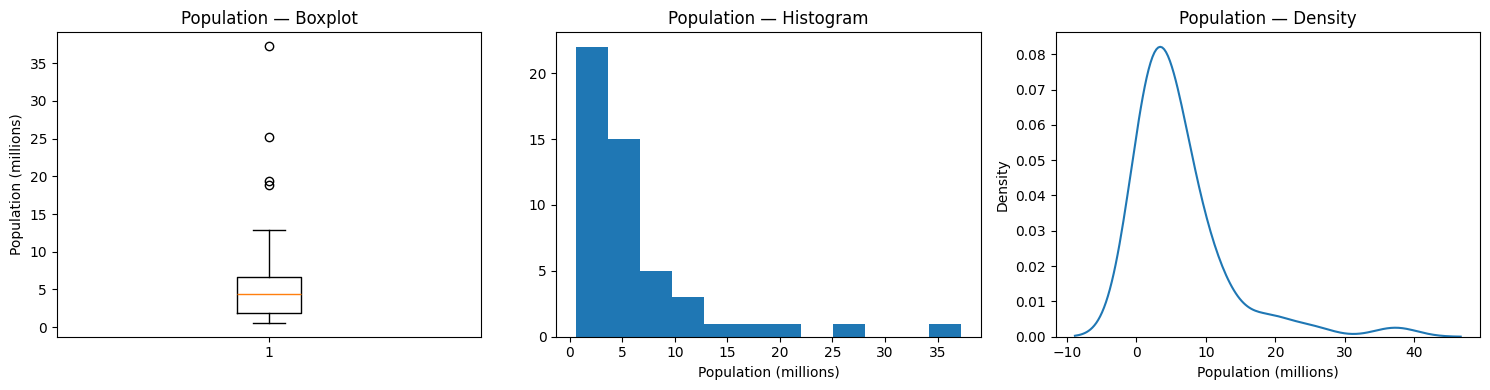

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot
axes[0].boxplot(population / 1_000_000)
axes[0].set_title("Population — Boxplot")
axes[0].set_ylabel("Population (millions)")

# Histogram
axes[1].hist(population / 1_000_000, bins=12)
axes[1].set_title("Population — Histogram")
axes[1].set_xlabel("Population (millions)")

# Density
sns.kdeplot(x=population / 1_000_000, ax=axes[2])
axes[2].set_title("Population — Density")
axes[2].set_xlabel("Population (millions)")

plt.tight_layout()
plt.show()


Distribusi populasi terlihat **right-skewed**: sebagian besar negara bagian berada pada populasi yang relatif rendah, sedangkan sejumlah kecil negara bagian memiliki populasi sangat besar. Nilai ekstrem tersebut terlihat lebih jelas pada boxplot dan ekor kanan histogram/density plot.


In [10]:
# Percentile memberikan posisi data pada beberapa titik distribusi.
population_percentiles = population.quantile([0.05, 0.25, 0.50, 0.75, 0.95])
population_percentiles


,Population
0.05,6.895e+05
0.25,1.833e+06
0.50,4.436e+06
0.75,6.680e+06
0.95,1.912e+07


## 6. Exploring Binary and Categorical Data

Untuk data kategorikal, ringkasan seperti mean tidak selalu relevan. Kita lebih sering melihat:

- **frekuensi** setiap kategori;
- **proporsi** setiap kategori;
- **mode**, yaitu kategori yang paling sering muncul;
- **bar chart** untuk membandingkan kategori.

Buku menggunakan data penyebab keterlambatan penerbangan di Dallas/Fort Worth (DFW) sebagai contoh.


In [11]:
dfw = load_book_data("dfw_airline.csv")
dfw


,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


In [12]:
# Data pada contoh buku berisi jumlah delay menurut penyebab.
delay_counts = dfw.iloc[0]
delay_percent = 100 * delay_counts / delay_counts.sum()
delay_percent.sort_values(ascending=False)


,0
Inbound,42.428
ATC,30.401
Carrier,23.023
Weather,4.025
Security,0.123


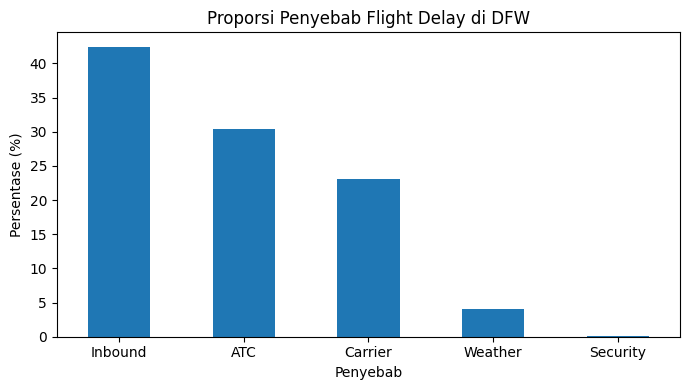

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
delay_percent.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Proporsi Penyebab Flight Delay di DFW")
ax.set_xlabel("Penyebab")
ax.set_ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Bar chart membuat perbandingan antar kategori menjadi lebih mudah. Berbeda dengan histogram, setiap batang di sini mewakili **kategori yang sudah ditentukan**, bukan interval numerik yang dibuat dari data.


## 7. Correlation

**Correlation** mengukur arah dan kekuatan hubungan linear antara dua variabel numerik.

Koefisien korelasi Pearson berada pada rentang **−1 sampai +1**:

- mendekati **+1** → hubungan linear positif kuat;
- mendekati **−1** → hubungan linear negatif kuat;
- mendekati **0** → hubungan linear lemah atau tidak ada.

Korelasi bukan berarti hubungan sebab-akibat. Dua variabel dapat bergerak bersama karena faktor lain.


In [14]:
# Data return saham S&P 500 yang digunakan pada contoh buku.
sp500_sectors = load_book_data("sp500_sectors.csv")
sp500_data = load_book_data("sp500_data.csv.gz", index_col=0)

telecom_symbols = sp500_sectors.loc[
    sp500_sectors["sector"] == "telecommunications_services",
    "symbol"
]

telecom = sp500_data.loc[:, sp500_data.columns.isin(telecom_symbols)]
telecom = telecom[telecom.index > "2012-07-01"]

correlations = telecom.corr()
correlations


,T,CTL,FTR,VZ,LVLT
T,1.000,0.475,0.328,0.678,0.279
CTL,0.475,1.000,0.420,0.417,0.287
FTR,0.328,0.420,1.000,0.287,0.260
VZ,0.678,0.417,0.287,1.000,0.242
LVLT,0.279,0.287,0.260,0.242,1.000


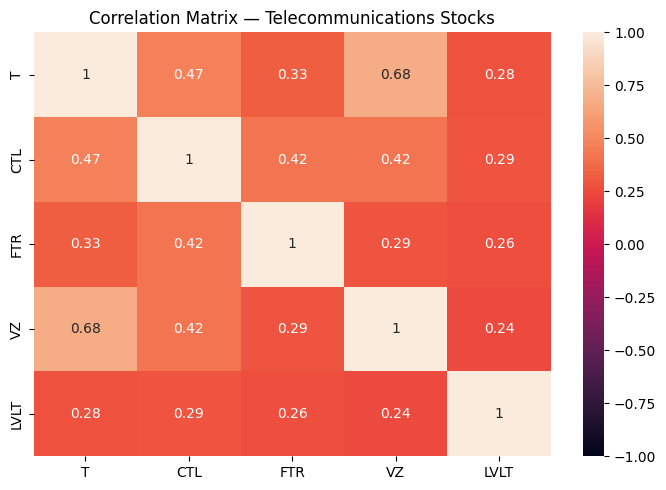

In [15]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlations, annot=True, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Telecommunications Stocks")
plt.tight_layout()
plt.show()


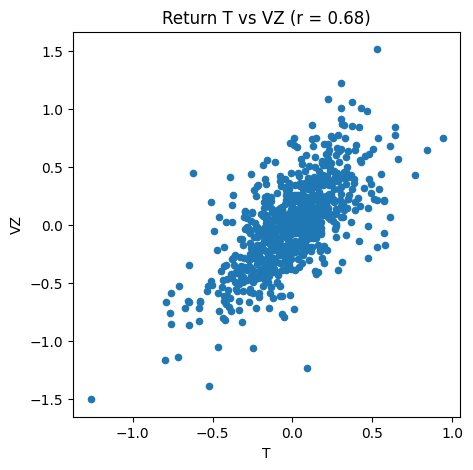

In [16]:
# Contoh scatterplot dua saham yang digunakan dalam pembahasan.
if {"T", "VZ"}.issubset(telecom.columns):
    corr_tv = correlations.loc["T", "VZ"]

    ax = telecom.plot.scatter(
        x="T",
        y="VZ",
        figsize=(5, 5),
        marker="o"
    )
    ax.set_xlabel("T")
    ax.set_ylabel("VZ")
    ax.set_title(f"Return T vs VZ (r = {corr_tv:.2f})")
    plt.show()
else:
    print("Kolom T dan VZ tidak tersedia pada subset data yang dimuat.")


Korelasi yang relatif tinggi antara dua saham dalam sektor yang sama menunjukkan bahwa pergerakan keduanya dapat memiliki pola yang serupa. Namun, angka korelasi hanya menjelaskan hubungan linear pada data yang diamati; ia tidak membuktikan bahwa satu saham menyebabkan perubahan pada saham lainnya.


## 8. Exploring Two or More Variables

Saat dua atau lebih variabel dianalisis bersama, jenis visualisasi dipilih berdasarkan tipe dan jumlah data.

Contoh dari buku:

- **Numerik vs numerik** → scatterplot atau hexbin plot.
- **Kategorikal vs kategorikal** → contingency table.
- **Kategorikal vs numerik** → boxplot/grouped comparison.
- Untuk data sangat besar, scatterplot dapat mengalami **overplotting**, sehingga hexbin dapat lebih informatif.


In [17]:
# Data properti King County digunakan untuk contoh hubungan dua variabel numerik.
kc_tax = load_book_data("kc_tax.csv.gz")

kc_tax0 = kc_tax.loc[
    (kc_tax["TaxAssessedValue"] < 750000)
    & (kc_tax["SqFtTotLiving"] > 100)
    & (kc_tax["SqFtTotLiving"] < 3500)
].copy()

print("Jumlah observasi setelah filter:", len(kc_tax0))
kc_tax0[["TaxAssessedValue", "SqFtTotLiving"]].head()


Jumlah observasi setelah filter: 432693


,TaxAssessedValue,SqFtTotLiving
1,206000.0,1870
2,303000.0,1530
3,361000.0,2000
4,459000.0,3150
5,223000.0,1570


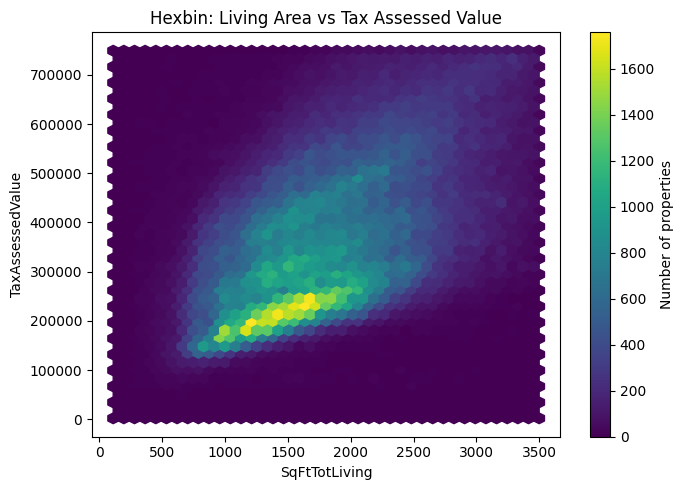

In [18]:
# Hexbin mengurangi masalah overplotting dengan mengelompokkan observasi ke dalam sel.
fig, ax = plt.subplots(figsize=(7, 5))

hb = ax.hexbin(
    kc_tax0["SqFtTotLiving"],
    kc_tax0["TaxAssessedValue"],
    gridsize=40
)

ax.set_xlabel("SqFtTotLiving")
ax.set_ylabel("TaxAssessedValue")
ax.set_title("Hexbin: Living Area vs Tax Assessed Value")
fig.colorbar(hb, ax=ax, label="Number of properties")

plt.tight_layout()
plt.show()


Dengan ratusan ribu observasi, scatterplot biasa dapat membuat titik saling menutupi. **Hexbin** merangkum kepadatan observasi sehingga pola hubungan antara luas bangunan dan nilai pajak lebih mudah dilihat.


In [19]:
# Contingency table: hubungan dua variabel kategorikal.
lc_loans = load_book_data("lc_loans.csv")

loan_table = pd.crosstab(
    lc_loans["grade"],
    lc_loans["status"]
)

loan_table


status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,1562,50051,20408,469
B,5302,93852,31160,2056
C,6023,88928,23147,2777
D,5007,53281,13681,2308
E,2842,24639,5949,1374
F,1526,8444,2328,606
G,409,1990,643,199


In [20]:
# Proporsi tiap status di dalam masing-masing grade.
loan_proportion = loan_table.div(
    loan_table.sum(axis=1),
    axis=0
)

loan_proportion.round(3)


status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,0.022,0.690,0.282,0.006
B,0.040,0.709,0.235,0.016
C,0.050,0.736,0.191,0.023
D,0.067,0.717,0.184,0.031
E,0.082,0.708,0.171,0.039
F,0.118,0.654,0.180,0.047
G,0.126,0.614,0.198,0.061


Contingency table menunjukkan jumlah kombinasi kategori. Mengubahnya menjadi proporsi per baris membantu membandingkan distribusi status pinjaman antar-grade dengan ukuran kelompok yang berbeda.


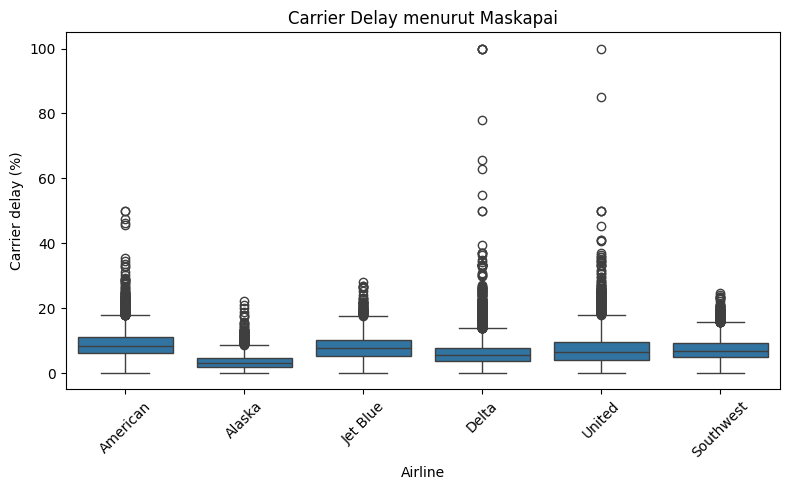

In [21]:
# Kategori vs numerik: membandingkan distribusi persentase delay antar maskapai.
airline_stats = load_book_data("airline_stats.csv")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=airline_stats,
    x="airline",
    y="pct_carrier_delay",
    ax=ax
)

ax.set_title("Carrier Delay menurut Maskapai")
ax.set_xlabel("Airline")
ax.set_ylabel("Carrier delay (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Boxplot berkelompok memungkinkan kita membandingkan **median, penyebaran, dan kemungkinan outlier** dari variabel numerik pada beberapa kategori. Ini merupakan contoh bagaimana dua variabel dapat dianalisis secara bersamaan tanpa hanya melihat satu ringkasan angka.


# Kesimpulan Bab 1

EDA merupakan tahap untuk **memahami data sebelum melakukan analisis yang lebih jauh**.

Hal utama yang dipelajari:

1. Kenali tipe dan struktur data terlebih dahulu.
2. Gunakan mean, median, trimmed mean, atau weighted measures untuk melihat lokasi data.
3. Gunakan standard deviation, MAD, range, dan IQR untuk melihat variabilitas.
4. Gunakan boxplot, histogram, dan density plot untuk memahami distribusi.
5. Untuk data kategorikal, frekuensi, proporsi, dan bar chart lebih sesuai.
6. Korelasi mengukur hubungan linear, bukan sebab-akibat.
7. Saat menganalisis beberapa variabel, pilih visualisasi sesuai tipe data dan jumlah observasi.
8. Untuk data yang sangat banyak, teknik seperti hexbin dapat membantu mengatasi overplotting.

Dengan demikian, EDA membantu kita menemukan pola, penyimpangan, dan karakteristik penting sebelum membangun model statistik atau machine learning.
